# Shot-by-Shot Noise Visualization on Odra

Single test sample classified 100 times (1 shot each) on IQM Spark ODRA 5.  

In [1]:
import subprocess, sys

try:
    import qiskit, iqm.qiskit_iqm, sklearn, torch
    from iqm.qiskit_iqm import IQMProvider  # verify full install
    print("All dependencies already available.")
except (ImportError, RuntimeError, ModuleNotFoundError):
    subprocess.call([sys.executable, "-m", "pip", "uninstall", "-y", "qiskit-iqm"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
    import qiskit, iqm.qiskit_iqm, sklearn, torch
    print("Dependencies installed and loaded.")

All dependencies already available.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from ucimlrepo import fetch_ucirepo
from iqm.qiskit_iqm import IQMProvider

In [ ]:
NUM_QUBITS = 5
ANSATZ_DEPTH = 2
N_SHOTS = 100
WEIGHTS_PATH = "weights.pth"


def ansatz(n_qubits, depth):
    """Ring topology ansatz"""
    params_per_iter = 4 * n_qubits
    theta = ParameterVector('\u03b8', params_per_iter * (depth // 2))
    qc = QuantumCircuit(n_qubits)

    for j in range(depth // 2):
        offset = j * params_per_iter

        for i in range(n_qubits):
            qc.ry(theta[offset + i], i)
        for i in range(n_qubits):
            target = (i + 1) % n_qubits
            qc.rz(theta[offset + n_qubits + i], target)
            qc.cz(i, target)

        offset_l2 = offset + 2 * n_qubits

        for i in range(n_qubits):
            qc.rx(theta[offset_l2 + i], i)
        for i in range(n_qubits):
            target = (i - 1) % n_qubits
            qc.ry(theta[offset_l2 + n_qubits + i], target)
            qc.cz(i, target)

    return qc

In [4]:
# Reproduce model_odra data pipeline
banknote = fetch_ucirepo(id=267)
X = banknote.data.features.to_numpy()
y = banknote.data.targets.to_numpy().ravel()

interaction = (X[:, 0] * X[:, 1]).reshape(-1, 1)
X = np.hstack((X, interaction))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = MinMaxScaler(feature_range=(0, np.pi))
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

# Pick random test sample
sample_idx = np.random.randint(0, len(X_test_scaled))
sample = X_test_scaled[sample_idx]
true_label = int(y_test[sample_idx])  # 0 or 1

print(f"Sample #{sample_idx} | True label: {true_label}")
print(f"Features: {sample}")

Sample #55 | True label: 1
Features: [1.6554865  1.9019868  0.32781965 2.3314373  1.597694  ]


In [5]:
# Feature map
input_params = ParameterVector('x', NUM_QUBITS)
feature_map = QuantumCircuit(NUM_QUBITS)
for i in range(NUM_QUBITS):
    feature_map.ry(input_params[i], i)

# Ansatz
ansatz_circuit = ansatz(NUM_QUBITS, ANSATZ_DEPTH)

# Full circuit
qc = QuantumCircuit(NUM_QUBITS)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz_circuit, inplace=True)
qc.measure_all()

# Load trained weights
state_dict = torch.load(WEIGHTS_PATH, map_location="cpu")
weights = state_dict['quantum_layer.weight'].detach().numpy()
print(f"Loaded {len(weights)} weights from {WEIGHTS_PATH}")

# Bind all parameters (input features + ansatz weights)
param_dict = {}
for i, p in enumerate(input_params):
    param_dict[p] = float(sample[i])
for i, p in enumerate(ansatz_circuit.parameters):
    param_dict[p] = float(weights[i])

bound_qc = qc.assign_parameters(param_dict)
print(f"Circuit ready: {bound_qc.num_qubits} qubits, depth {bound_qc.depth()}")

Loaded 20 weights from weights.pth
Circuit ready: 5 qubits, depth 20


In [ ]:
from iqm.iqm_server_client.iqm_server_client import _IQMServerClient
_orig_resolve = _IQMServerClient._resolve_quantum_computer

def _patched_resolve(self, user_defined_quantum_computer):
    try:
        return _orig_resolve(self, user_defined_quantum_computer)
    except Exception:
        return user_defined_quantum_computer or "default"

_IQMServerClient._resolve_quantum_computer = _patched_resolve

provider = IQMProvider("https://odra5.e-science.pl/", token=input("Enter IQM Token: "))
backend = provider.get_backend()
print(f"Connected to: {backend.name}")

transpiled_qc = transpile(bound_qc, backend, optimization_level=0)
print(f"Transpiled circuit depth: {transpiled_qc.depth()}")

Connected to: IQMBackend
Transpiled circuit depth: 53


In [7]:
# Run 100 individual shots on Odra
# Each iteration = 1 job with shots=1 -> one raw qubit-0 measurement
classifications = []

for shot in tqdm(range(N_SHOTS), desc="Running shots on Odra"):
    try:
        job = backend.run(transpiled_qc, shots=1)
        result = job.result()
        counts = result.get_counts()
        bitstring = list(counts.keys())[0]
        qubit_0 = int(bitstring[-1])  # little-endian: last char = qubit 0
        # |0> on qubit 0 -> Z eigenvalue +1 -> class 1
        # |1> on qubit 0 -> Z eigenvalue -1 -> class 0
        classifications.append(1 - qubit_0)
    except Exception as e:
        print(f"\nShot {shot + 1} failed: {e}")
        classifications.append(-1)

classifications = np.array(classifications)
valid = classifications >= 0

# Save results to disk so plot cell works independently
np.savez('odra_results.npz', classifications=classifications, sample_idx=sample_idx, true_label=true_label)
print(f"Results saved to odra_results.npz")

print(f"\nCompleted: {valid.sum()}/{N_SHOTS} shots")
print(f"Class 0: {np.sum(classifications[valid] == 0)} | Class 1: {np.sum(classifications[valid] == 1)}")

Running shots on Odra:   0%|          | 0/100 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

...

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Progress in queue:   0%|          | 0/1 [00:00<?, ?it/s]

Results saved to odra_results.npz

Completed: 100/100 shots
Class 0: 28 | Class 1: 72


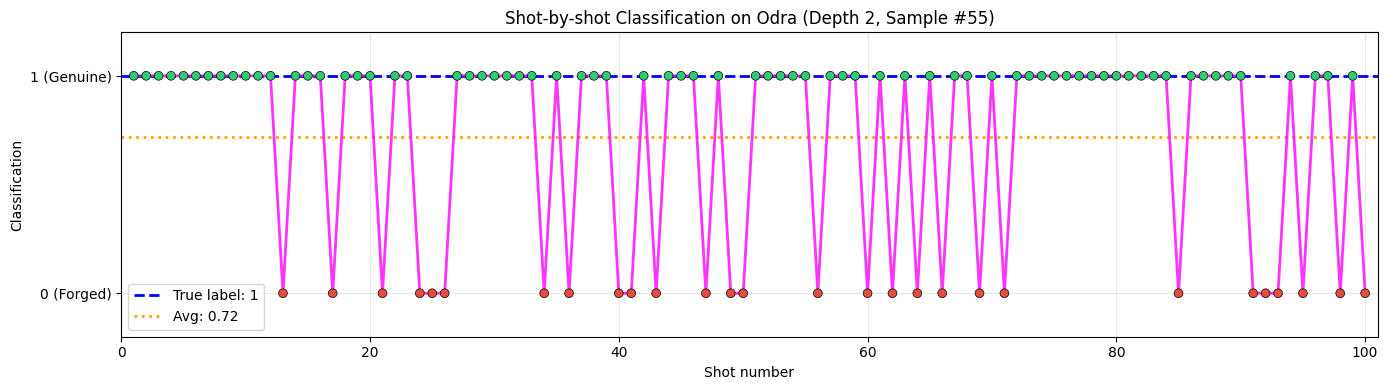

Expectation value: 0.4400
Majority vote: class 1 | True label: 1 | Correct: True


In [ ]:
# Load results from file
try:
    classifications
except NameError:
    data = np.load('odra_results.npz')
    classifications = data['classifications']
    sample_idx = int(data['sample_idx'])
    true_label = int(data['true_label'])
    print("Loaded results from odra_results.npz")

valid = classifications >= 0

fig, ax = plt.subplots(figsize=(14, 4))

shots = np.arange(1, len(classifications) + 1)
colors = ['#e74c3c' if c == 0 else '#2ecc71' for c in classifications]

# Line connecting consecutive shots
ax.plot(shots[valid], classifications[valid], color='magenta', linewidth=2, alpha=0.8, zorder=4)

ax.scatter(shots[valid], classifications[valid], c=[colors[i] for i in range(len(colors)) if valid[i]],
           s=40, zorder=5, edgecolors='black', linewidths=0.5)

ax.axhline(y=true_label, color='blue', linestyle='--', linewidth=2,
           label=f'True label: {true_label}')

avg = np.mean(classifications[valid])
ax.axhline(y=avg, color='orange', linestyle=':', linewidth=2,
           label=f'Avg: {avg:.2f}')

ax.set_xlabel('Shot number')
ax.set_ylabel('Classification')
ax.set_title(f'Shot-by-shot Classification on Odra (Depth {ANSATZ_DEPTH}, Sample #{sample_idx})')
ax.set_yticks([0, 1])
ax.set_yticklabels(['0 (Forged)', '1 (Genuine)'])
ax.set_xlim(0, len(classifications) + 1)
ax.set_ylim(-0.2, 1.2)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
majority = 1 if np.sum(classifications[valid] == 1) > valid.sum() / 2 else 0
exp_val = 2 * np.mean(classifications[valid]) - 1
print(f"Expectation value: {exp_val:.4f}")
print(f"Majority vote: class {majority} | True label: {true_label} | Correct: {majority == true_label}")